<a href="https://colab.research.google.com/github/jc39963/Explainable_DL/blob/main/Explainable_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Applying GradCAM to Image Classification
### Jenny Chen

#### Include the button below. Change the link to the location in your github repository:
#### Example: https://colab.research.google.com/github/yourGHName/yourREPOName/blob/yourBranchName/yourFileName.ipynb


[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jc39963/Explainable_DL/blob/main/Explainable_DL.ipynb)

### Purpose
- To classify and identify if MRI images have a tumor or not.
- [Brain MRI Images for Brain Tumor Detection from Kaggle](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection)

In [23]:
#!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=6565369f6aad2d8c1ef2806a2b6439b4223c3d9e498a2c8309849b2be5cb3e1f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [39]:
import kagglehub
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import models
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM, ScoreCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [7]:


path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [10]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load entire dataset
dataset = datasets.ImageFolder("/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/", transform=transform)

# Split into train/test (80/20)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

# Create loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32)

In [12]:
# loading in pretrained model:

model = models.resnet50(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


In [13]:
for param in model.parameters():
    param.requires_grad = False


In [14]:
# for last layer specific to my data
num_classes = 2  # yes/no
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [19]:
# retrain last layer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(5):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.4904
Epoch 2, Loss: 0.5363
Epoch 3, Loss: 0.3876
Epoch 4, Loss: 0.3270
Epoch 5, Loss: 0.3071


In [20]:
#evaluate
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 80.39%


### GradCAM and Variants

In [25]:
img_path = "/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes/Y1.jpg"
rgb_img = np.array(Image.open(img_path).convert("RGB"))
input_tensor = transform(Image.open(img_path)).unsqueeze(0)

In [27]:
model.eval()  # keep this to disable dropout/batchnorm randomness
torch.set_grad_enabled(True)  # <-- turn gradients back on


torch.autograd.grad_mode.set_grad_enabled(mode=True)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Make sure the input is on the same device
input_tensor = input_tensor.to(device)

In [36]:
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Forward pass to get predicted class
outputs = model(input_tensor)
pred_class = outputs.argmax(dim=1).item()

# Run Grad-CAM for that class
targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]


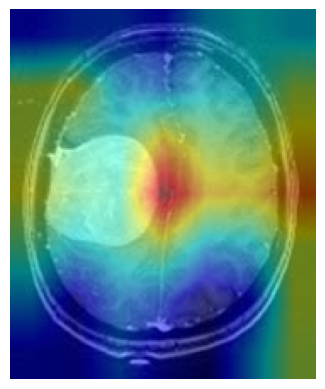

In [40]:
rgb_img_float = rgb_img.astype(np.float32) / 255


# Make sure both have the same width/height
grayscale_cam_resized = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))
visualization = show_cam_on_image(rgb_img_float, grayscale_cam_resized, use_rgb=True)

plt.imshow(visualization)
plt.axis('off')
plt.show()



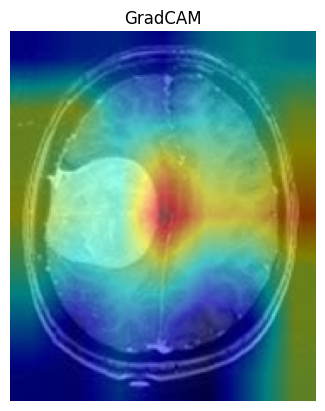

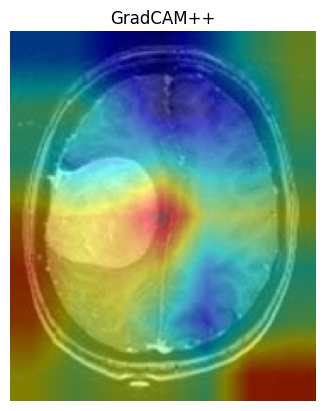

100%|██████████| 128/128 [00:07<00:00, 17.46it/s]


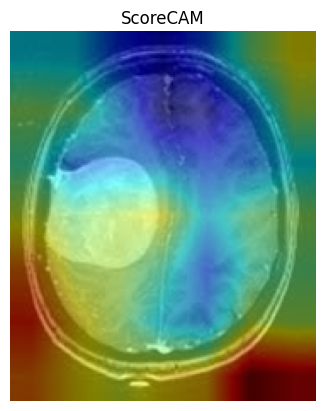

In [42]:
gradcam_pp = GradCAMPlusPlus(model=model, target_layers=target_layers)
scorecam   = ScoreCAM(model=model, target_layers=target_layers)

for method, name in [(cam, "GradCAM"), (gradcam_pp, "GradCAM++"), (scorecam, "ScoreCAM")]:
    grayscale_cam = method(input_tensor=input_tensor)[0, :]
    grayscale_cam_resized = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam_resized, use_rgb=True)
    plt.title(name)
    plt.imshow(visualization)
    plt.axis('off')
    plt.show()
